---
title: "6.2 Regression Kriging with H2O"
execute:
  enabled: false
---


# 6.2 Regression Kriging with H2O



**Dataset:** Great Plains soil survey (`data/gp_data_5000.csv`, `data/gp_grid.csv`)  

**Target:** Soil Organic Carbon (SOC, %)  

**Covariates:** NDVI, MAP, MAT, elevation, slope, TPI, aspect, K-factor, silt+clay, **NLCD (categorical)**

**Library:** `pygstat` v0.1.0 — `RegressionKrigingH2O`, `H2O_MODEL_TYPES`

---



## Table of Contents

1. [Overview](#1-overview)
2. [Mathematical Formulation](#2-mathematical-formulation)
3. [Python Setup](#3-python-setup)
   - 3.1 [CPU and GPU](#31-cpu-and-gpu)
4. [Load and Explore the Great Plains Data](#4-load-and-explore-the-great-plains-data)
5. [Prepare Features](#5-prepare-features)
6. [Stratified Train / Valid / Test Split](#6-stratified-train--valid--test-split)
7. [Exploratory Variogram of SOC](#7-exploratory-variogram-of-soc)
8. [Fit H2O Regression-Kriging Families](#8-fit-h2o-regression-kriging-families)
9. [Hold-Out Comparison on the Test Set](#9-hold-out-comparison-on-the-test-set)
10. [Feature Importance](#10-feature-importance)
11. [Predict SOC on Grid Locations](#11-predict-soc-on-grid-locations)
12. [Map Predictions](#12-map-predictions)
13. [CPU vs GPU RK Timing](#13-cpu-vs-gpu-rk-timing)
14. [Summary and Conclusions](#14-summary-and-conclusions)
15. [Resources](#15-resources)


***
## 1. Overview

**Regression Kriging (RK)** combines a **deterministic trend** (here, an H2O supervised model of SOC from environmental covariates) with **ordinary kriging of the residuals**. At location $\mathbf{s}$,

$$
Z(\mathbf{s}) = \hat{m}(\mathbf{s}) + \hat{e}(\mathbf{s})
$$

where $\hat{m}(\mathbf{s})$ is the H2O prediction and $\hat{e}(\mathbf{s})$ is the kriged residual. Tutorial 7.1 uses scikit-learn-style trend models; this notebook uses **H2O-3** via `pygstat.RegressionKrigingH2O`.

[H2O](https://h2o.ai) is an open-source, JVM-backed machine-learning platform. `RegressionKrigingH2O(model_type=...)` wraps one H2O algorithm (or AutoML) as the RK trend, then fits a residual variogram and ordinary kriging exactly as in 7.1.

### This tutorial

We map **soil organic carbon** across the US Great Plains using **5,000** samples and a ~10 km prediction grid. **NLCD** land-cover class is kept as a **categorical** factor (H2O dummy-encodes it). Samples are split **stratified by NLCD** into **train / valid / test**. Train plus valid are used to **fit and tune** each family; the **best model of each family** is scored on the **test set** and then used to **predict SOC at grid locations**. Section 13 times residual **ordinary kriging** on **CPU vs GPU** for prefixes of `data/gp_data_5000.csv`.



### H2O trend families (`H2O_MODEL_TYPES`)

| `model_type` | H2O estimator | Role in this notebook |
|--------------|---------------|------------------------|
| `'glm'` | `H2OGeneralizedLinearEstimator` | Elastic-net GLM (Gaussian family). `alpha` interpolates ridge ($0$) and lasso ($1$). Fast, interpretable coefficients. |
| `'drf'` | `H2ORandomForestEstimator` | Distributed Random Forest: bagged trees with random feature subsets. Robust baseline for nonlinear tabular trends. |
| `'gbm'` | `H2OGradientBoostingEstimator` | H2O's native gradient-boosting machine. Sequential trees fit residual error; sensitive to `learn_rate` / `max_depth`. |
| `'xgboost'` | `H2OXGBoostEstimator` | H2O wrapper around XGBoost. Same job as `'gbm'` with a different boosting backend (skipped if the H2O build has no XGBoost). |
| `'stacked_ensemble'` | `H2OStackedEnsembleEstimator` | Stacks **DRF + GBM + GLM** base learners trained with cross-validation; a metalearner combines out-of-fold predictions. |
| `'automl'` | `H2OAutoML` | Searches GLM, DRF, GBM, XGBoost, Deep Learning, and stacked ensembles; the **leader** is the trend model. |

Pass `tune_hyperparameters=True` (any type except `'automl'` and `'stacked_ensemble'`) to run an H2O grid search. An explicit validation frame (`X_valid`, `y_valid` in `fit()`) is used for **early stopping and ranking**; residual kriging is still fit on **training** residuals only.

`categorical_columns=['NLCD']` converts land cover to an H2O factor so the codes are not treated as a continuous scale.



***
## 2. Mathematical Formulation

The target $Z(\mathbf{s})$ at location $\mathbf{s}$ is

$$
Z(\mathbf{s}) = \mu(\mathbf{s}) + \varepsilon(\mathbf{s})
$$

where $\mu(\mathbf{s})$ is a **deterministic trend** explained by covariates and $\varepsilon(\mathbf{s})$ is a **zero-mean, spatially autocorrelated residual**.

### Fit an H2O trend

Covariates $\mathbf{x}(\mathbf{s})$ (NDVI, climate, terrain, soils, NLCD class) enter an H2O model $f_{\theta}$:

$$
\hat{\mu}(\mathbf{s}) = f_{\theta}\bigl(\mathbf{x}(\mathbf{s})\bigr)
$$

Hyperparameters $\theta$ (trees, depth, `alpha`, …) are chosen on the **validation** set. AutoML instead searches a library of algorithms and returns the leader.

### Residuals and variogram

$$
e_i = z_i - \hat{\mu}(\mathbf{s}_i), \quad i = 1, \ldots, n_{\mathrm{train}}
$$

$$
\hat{\gamma}(h) = \frac{1}{2|N(h)|} \sum_{(i,j) \in N(h)} (e_i - e_j)^2
$$

Spherical model:

$$
\gamma(h) =
\begin{cases}
c_0 + c \left(1.5 \frac{h}{a} - 0.5 \left(\frac{h}{a}\right)^3 \right), & h < a \\
c_0 + c, & h \geq a
\end{cases}
$$

### Ordinary kriging of residuals

$$
\hat{\varepsilon}(\mathbf{s}_0) = \sum_{i=1}^{n} \lambda_i e_i
$$

with the usual unbiasedness constraint $\sum_i \lambda_i = 1$. Final prediction:

$$
\hat{Z}(\mathbf{s}_0) = \hat{\mu}(\mathbf{s}_0) + \hat{\varepsilon}(\mathbf{s}_0)
$$

Kriging variance $\sigma_K^2(\mathbf{s}_0)$ is reported as a standard error when `return_std=True`.

### Why H2O for the trend?

| Method | Pros | Cons |
|--------|------|------|
| sklearn ensembles (tutorial 7.1) | Simple Python API | No AutoML / GLM factor encoding out of the box |
| H2O GLM / DRF / GBM / XGBoost | Native categoricals, grid search, validation frames | Requires Java / H2O cluster |
| H2O AutoML | Algorithm + hyperparameter search, stacked leader | Longer runtime |

### Real-world example: soil organic carbon

- **Covariates:** NDVI, MAP, MAT, elevation, slope, TPI, aspect, K-factor, silt+clay, NLCD class
- **Trend:** SOC tends to increase with NDVI and MAP; land cover is a class effect, not a numeric score
- **Residuals:** unmeasured soil type, management, and local climate
- **RK:** H2O captures the **global / nonlinear trend**; kriging adds **local spatial structure**



***
## 3. Python Setup

### 3.1 CPU and GPU

`RegressionKrigingH2O` fits the H2O trend on the **JVM / CPU**, then builds the residual covariance and solves the **ordinary kriging** system on **CPU** (NumPy/SciPy) or **GPU** (CuPy). Pass `use_gpu` as:

| Value | Behaviour |
|-------|-----------|
| `'auto'` (default) | GPU when CuPy can run a kernel on this card. Falls back to CPU otherwise. |
| `True` | Force GPU. Warns and falls back to CPU if CuPy is missing or cannot run a kernel. |
| `False` | Always CPU (NumPy/SciPy). |

This notebook probes the GPU once with `cupy_gpu_usable()` (a real op, not just `import cupy`) and stores the result in `USE_GPU`. Every `RegressionKrigingH2O(...)` call below passes `use_gpu=USE_GPU`, so the same cells run on a laptop CPU or a CUDA workstation without edits.

The **linear-algebra** steps that move to the GPU are the $n \times n$ residual covariance, the $n_{\text{pred}} \times n$ covariance to the targets, and the augmented OK solve. The H2O trend itself always stays on CPU.

Install CuPy with `pip install pygstat[gpu]` (CUDA 11) or `pip install cupy-cuda12x` for CUDA 12.

Section 13 times residual OK (the kriging step inside `RegressionKrigingH2O`) on both backends using prefixes of `data/gp_data_5000.csv`.


In [1]:
%matplotlib inline

import warnings
from collections import Counter
from pathlib import Path

import geopandas as gpd
import h2o
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from IPython.display import display
import os
import sys

sys.path.insert(0, os.path.abspath("../src"))

import pygstat
from pygstat import H2O_MODEL_TYPES, RegressionKrigingH2O, Variogram
from pygstat.utils.backend import CUPY_AVAILABLE, cupy_gpu_usable

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", lambda v: f"{v:0.3f}")

print("H2O_MODEL_TYPES:", H2O_MODEL_TYPES)
print("h2o version    :", h2o.__version__)

if h2o.connection() is None:
    h2o.init(max_mem_size="8G", nthreads=-1)

try:
    from h2o.estimators import H2OXGBoostEstimator
    HAS_XGBOOST = bool(H2OXGBoostEstimator.available())
except Exception:
    HAS_XGBOOST = False

print("H2O XGBoost available:", HAS_XGBOOST)

# ── CPU / GPU dispatch ────────────────────────────────────────────────────────
# cupy_gpu_usable() runs a real kernel (not just `import cupy`). Older cards can
# import CuPy and still fail at compile time; those stay on CPU.
print(f"pygstat version : {pygstat.__version__}")
print(f"NumPy           : {np.__version__}")
print(f"pandas          : {pd.__version__}")
USE_GPU = cupy_gpu_usable()
if USE_GPU:
    import cupy as cp
    print(f"CuPy            : {cp.__version__}")
    try:
        name = cp.cuda.runtime.getDeviceProperties(0)["name"]
        if isinstance(name, bytes):
            name = name.decode()
        print(f"GPU             : {name}")
    except Exception:
        print("GPU             : available")
    print("Backend         : GPU (CuPy) — residual OK covariance + solve on GPU")
else:
    if CUPY_AVAILABLE:
        import cupy as cp
        print(f"CuPy            : {cp.__version__} (installed, but cannot run a kernel on this GPU/CUDA setup)")
    else:
        print("CuPy            : not installed  (pip install pygstat[gpu]  or  cupy-cuda12x)")
    print("Backend         : CPU (NumPy)")
print(f"use_gpu         : {USE_GPU}")




I0000 00:00:1788925687.142408  553197 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


H2O_MODEL_TYPES: ('automl', 'deep_learning', 'drf', 'glm', 'gam', 'gbm', 'xgboost', 'uplift_drf', 'stacked_ensemble')
h2o version    : 3.46.0.12
Checking whether there is an H2O instance running at http://localhost:54321.

 connected.


H2O_cluster_uptime:,9 hours 52 mins
H2O_cluster_timezone:,America/New_York
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.12
H2O_cluster_version_age:,"28 days, 9 hours and 54 minutes"
H2O_cluster_name:,H2O_from_python_zia207_eod904
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,31.90 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"



+------------------------------------------------------------------+
| You are running the community edition of H2O-3 OSS.              |
|                                                                  |
| For commercial use, H2O-3 Secure is now recommended.             |
| This includes production support, CVE fixes, multi-node scaling, |
| model artifact extraction, and more.                             |
| See h2o.ai/h2o-3/oss-vs-secure for additional details.           |
| Contact enterprise@h2o.ai to upgrade.                            |
+------------------------------------------------------------------+


H2O XGBoost available: True
pygstat version : 0.1.0
NumPy           : 2.2.6
pandas          : 2.3.3
CuPy            : 14.2.0
GPU             : NVIDIA GeForce RTX 2080 Ti
Backend         : GPU (CuPy) — residual OK covariance + solve on GPU
use_gpu         : True


***
## 4. Load and Explore the Great Plains Data

Point samples live in `data/gp_data_5000.csv` (SOC plus covariates at 5,000 locations). The prediction grid is `data/gp_grid.csv` (covariates only). Coordinates are US Albers Equal Area (EPSG:5070), in metres.

The CSV header repeats `NLCD`; pandas renames the second copy to `NLCD.1`. That extra column is dropped. The first `NLCD` column matches the grid (classes 3–7).



In [2]:
DATA_DIR = Path("..") / "data"
df = pd.read_csv(DATA_DIR / "gp_data_5000.csv")
grid_df = pd.read_csv(DATA_DIR / "gp_grid.csv")
df = df.drop(columns=["NLCD.1"], errors="ignore")

print(f"Samples: {len(df):,}  |  Grid nodes: {len(grid_df):,}")
print("Sample columns:", list(df.columns))
print("Grid columns  :", list(grid_df.columns))
df.head()



Samples: 5,000  |  Grid nodes: 10,674
Sample columns: ['x', 'y', 'Aspect', 'ELEV', 'FRG', 'K_Factor', 'MAP', 'MAT', 'NDVI', 'NLCD', 'Silt_Clay', 'Slope', 'TPI', 'SOC']
Grid columns  : ['x', 'y', 'Aspect', 'ELEV', 'FRG', 'K_Factor', 'MAP', 'MAT', 'NDVI', 'NLCD', 'Silt_Clay', 'Slope', 'TPI']


,x,y,Aspect,ELEV,FRG,K_Factor,MAP,MAT,NDVI,NLCD,Silt_Clay,Slope,TPI,SOC
0,-955285,1723795,190.940,3253.481,3,0.215,509.138,1.762,0.556,4,43.669,16.048,-10.496,7.543
1,-735285,1973795,151.478,1464.636,2,0.213,346.082,9.494,0.598,7,48.345,1.105,-0.606,6.102
2,-975285,1103795,129.981,1441.645,133,0.113,372.746,15.772,0.240,5,38.460,12.090,2.134,3.612
3,-395285,1883795,143.176,841.139,2,0.320,548.891,10.720,0.483,6,87.090,2.587,-0.656,7.510
4,-925285,1173795,224.582,1490.576,3,0.284,357.764,14.428,0.216,5,53.868,6.122,0.595,2.378


In [3]:
print(df[["SOC", "NDVI", "MAP", "MAT", "ELEV", "Silt_Clay"]].describe().round(2))

NLCD_DES = {
    3: "Barren / other",
    4: "Forest",
    5: "Shrubland",
    6: "Herbaceous",
    7: "Planted/Cultivated",
}
print("\nNLCD classes (samples):")
print(
    df.groupby("NLCD").size().rename("n").to_frame()
    .assign(description=lambda s: s.index.map(NLCD_DES))
)



           SOC     NDVI      MAP      MAT     ELEV  Silt_Clay
count 5000.000 5000.000 5000.000 5000.000 5000.000   5000.000
mean     6.030    0.410  488.670    9.100 1657.040     53.890
std      3.700    0.160  213.480    4.180  743.290     16.410
min      0.030    0.050  153.580   -2.520  234.550      1.750
25%      3.240    0.270  345.480    6.290 1207.240     42.360
50%      5.120    0.380  424.780    9.570 1656.710     52.610
75%      8.030    0.530  585.630   12.420 2175.490     62.700
max     23.750    0.820 1749.110   17.880 3688.660     90.740

NLCD classes (samples):
         n         description
NLCD                          
3       19      Barren / other
4      956              Forest
5     1657           Shrubland
6     1519          Herbaceous
7      849  Planted/Cultivated


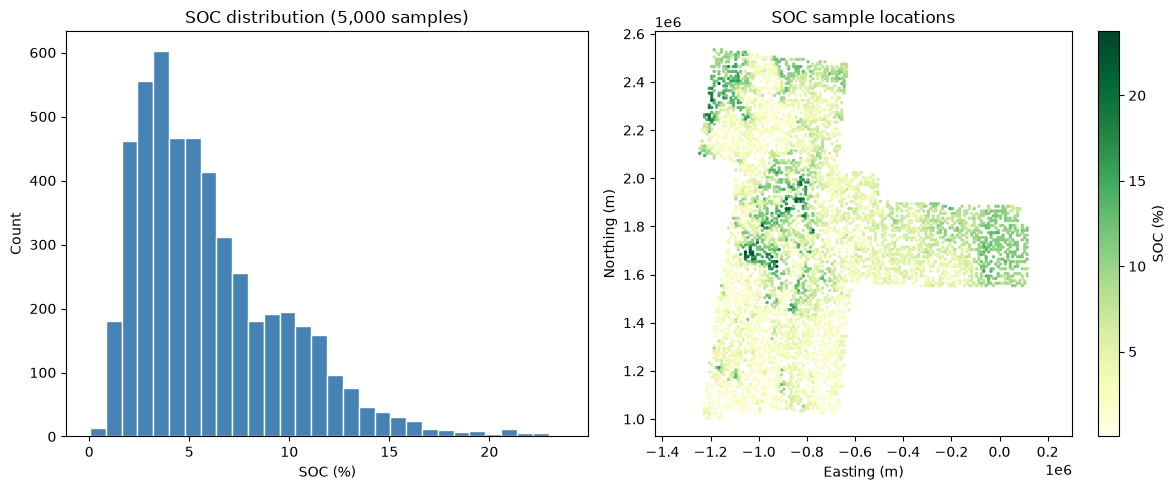

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(df["SOC"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_xlabel("SOC (%)")
axes[0].set_ylabel("Count")
axes[0].set_title("SOC distribution (5,000 samples)")

sc = axes[1].scatter(df["x"], df["y"], c=df["SOC"], s=6, cmap="YlGn", edgecolors="none")
axes[1].set_xlabel("Easting (m)")
axes[1].set_ylabel("Northing (m)")
axes[1].set_title("SOC sample locations")
axes[1].set_aspect("equal", adjustable="datalim")
fig.colorbar(sc, ax=axes[1], label="SOC (%)")
plt.tight_layout()
plt.show()



***
## 5. Prepare Features

Unlike tutorial 7.1, **NLCD is not recoded to an ordinal score**. It is passed as a **categorical** column (`categorical_columns=['NLCD']`) so GLM dummy-encodes the class and tree models split on it as a factor.



In [5]:
required_cols = [
    "x", "y", "NDVI", "MAP", "MAT", "ELEV", "Slope", "TPI",
    "Aspect", "K_Factor", "Silt_Clay", "NLCD",
]
for col in required_cols:
    if col not in df.columns or col not in grid_df.columns:
        raise ValueError(f"Missing column: {col}")

feature_cols = [
    "NDVI", "MAP", "MAT", "ELEV", "Slope", "TPI",
    "Aspect", "K_Factor", "Silt_Clay", "NLCD",
]
CATEGORICAL = ["NLCD"]

X = df[feature_cols].copy()
y = df["SOC"].to_numpy(dtype=float)
coords = df[["x", "y"]].to_numpy(dtype=float)
X_grid = grid_df[feature_cols].copy()
coords_grid = grid_df[["x", "y"]].to_numpy(dtype=float)
nlcd_labels = df["NLCD"].to_numpy()

print("Features:", feature_cols)
print("Categorical:", CATEGORICAL)
print("X:", X.shape, "  y:", y.shape, "  coords:", coords.shape)
print("Grid X:", X_grid.shape)
print("NLCD dtype (kept integer until H2O asfactor):", X["NLCD"].dtype)



Features: ['NDVI', 'MAP', 'MAT', 'ELEV', 'Slope', 'TPI', 'Aspect', 'K_Factor', 'Silt_Clay', 'NLCD']
Categorical: ['NLCD']
X: (5000, 10)   y: (5000,)   coords: (5000, 2)
Grid X: (10674, 10)
NLCD dtype (kept integer until H2O asfactor): int64


***
## 6. Stratified Train / Valid / Test Split

A **60% / 20% / 20%** split, stratified by NLCD so each land-cover class appears in train, valid, and test (`random_state=42`).

- **Train** — fit the H2O trend and the residual variogram / kriging
- **Valid** — H2O `validation_frame` (and AutoML leaderboard) for hyperparameter ranking and early stopping
- **Test** — untouched hold-out used only after the best model of each family is chosen



In [6]:
counts = Counter(nlcd_labels)
stratify_arg = nlcd_labels if min(counts.values()) >= 3 else None

(
    X_temp, X_test,
    y_temp, y_test,
    coords_temp, coords_test,
    nlcd_temp, nlcd_test,
) = train_test_split(
    X, y, coords, nlcd_labels,
    test_size=0.20,
    random_state=42,
    shuffle=True,
    stratify=stratify_arg,
)

(
    X_train, X_valid,
    y_train, y_valid,
    coords_train, coords_valid,
    nlcd_train, nlcd_valid,
) = train_test_split(
    X_temp, y_temp, coords_temp, nlcd_temp,
    test_size=0.25,  # 0.25 * 0.80 = 0.20 overall
    random_state=42,
    shuffle=True,
    stratify=nlcd_temp if stratify_arg is not None else None,
)

def _nlcd_counts(arr):
    return sorted(Counter(arr).items())

print(f"Train: {len(X_train):,}  |  Valid: {len(X_valid):,}  |  Test: {len(X_test):,}")
print("NLCD train:", _nlcd_counts(nlcd_train))
print("NLCD valid:", _nlcd_counts(nlcd_valid))
print("NLCD test :", _nlcd_counts(nlcd_test))



Train: 3,000  |  Valid: 1,000  |  Test: 1,000
NLCD train: [(np.int64(3), 11), (np.int64(4), 574), (np.int64(5), 995), (np.int64(6), 911), (np.int64(7), 509)]
NLCD valid: [(np.int64(3), 4), (np.int64(4), 191), (np.int64(5), 331), (np.int64(6), 304), (np.int64(7), 170)]
NLCD test : [(np.int64(3), 4), (np.int64(4), 191), (np.int64(5), 331), (np.int64(6), 304), (np.int64(7), 170)]


***
## 7. Exploratory Variogram of SOC

Before residual kriging, look at the **raw SOC** variogram on the training coordinates. Lag count uses Scott's rule on pairwise distances, capped at 30 lags: bin width $h = 3.5 \, \mathrm{std}\,/\, n^{1/3}$.



In [7]:
# Scott's rule on a random subset keeps the n=3,000 distance matrix light
rng = np.random.default_rng(42)
idx = rng.choice(len(coords_train), size=min(1200, len(coords_train)), replace=False)
sample_xy = coords_train[idx]
distances = np.sqrt(((sample_xy[:, None, :] - sample_xy[None, :, :]) ** 2).sum(axis=2))
upper_triangle = distances[np.triu_indices_from(distances, k=1)]
std_dist = np.nanstd(upper_triangle)
n_pairs = len(upper_triangle)
scott_bin_width = 3.5 * std_dist / (n_pairs ** (1 / 3))
maxlag_soc = float(np.nanpercentile(upper_triangle, 50))
n_lags_soc = max(5, min(30, int(maxlag_soc / scott_bin_width)))
print(f"Using Scott rule → n_lags: {n_lags_soc}, maxlag: {maxlag_soc:.1f} m")



Using Scott rule → n_lags: 30, maxlag: 601664.4 m


In [8]:
vg = Variogram(
    coords_train, y_train,
    model="spherical",
    estimator="matheron",
    maxlag=maxlag_soc,
    n_lags=n_lags_soc,
    use_gpu="auto",
)
vg.fit()
mask = ~np.isnan(vg.experimental)
rmse_vg = np.sqrt(np.mean((vg.experimental[mask] - vg(vg.lags)[mask]) ** 2))
nugget, psill, rng_m = vg.fitted_params
print(f"Spherical model RMSE: {rmse_vg:.2f}")
print(f"nugget={nugget:.3f}, partial sill={psill:.3f}, range={rng_m:.1f} m")



Spherical model RMSE: 0.51
nugget=3.209, partial sill=10.594, range=300832.2 m


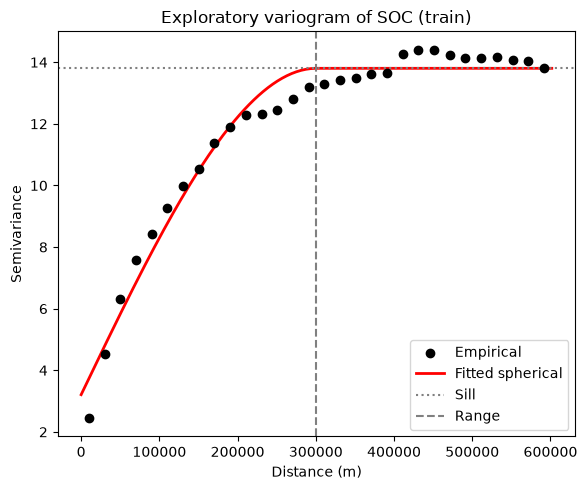

In [9]:
plt.figure(figsize=(6, 5))
plt.scatter(vg.lags, vg.experimental, color="black", label="Empirical", zorder=3)
h_fine = np.linspace(0, vg.maxlag, 200)
plt.plot(h_fine, vg(h_fine), color="red", linewidth=2, label="Fitted spherical")
plt.axhline(nugget + psill, color="gray", linestyle=":", label="Sill")
plt.axvline(rng_m, color="gray", linestyle="--", label="Range")
plt.xlabel("Distance (m)")
plt.ylabel("Semivariance")
plt.title("Exploratory variogram of SOC (train)")
plt.legend()
plt.tight_layout()
plt.show()



Residual variograms (next section) typically have a **shorter range** than the raw SOC variogram, because the regression has already absorbed the large-scale trend. Residual models use `maxlag=50` km and 15 lags — the same setting as tutorial 7.1.



***
## 8. Fit H2O Regression-Kriging Families

Each family is a `RegressionKrigingH2O` trend. GLM, DRF, GBM, and XGBoost run a **grid search** (`tune_hyperparameters=True`) with the validation frame as the score set. Stacked ensemble trains default DRF + GBM + GLM base learners. AutoML searches its algorithm library for `max_runtime_secs`.

The **best model of each family** (grid winner or AutoML leader) is kept, its **training residuals** are kriged, and that RK model is what we take to the test set and the grid.



In [10]:
VARIOGRAM_KWARGS = {"maxlag": 50_000, "n_lags": 15}

HYPER_PARAMS = {
    "glm": {"alpha": [0.0, 0.25, 0.5, 0.75, 1.0]},
    "drf": {"ntrees": [50, 100, 200], "max_depth": [10, 20]},
    "gbm": {"ntrees": [50, 100], "max_depth": [3, 5], "learn_rate": [0.05, 0.1]},
    "xgboost": {"ntrees": [50, 100], "max_depth": [3, 5], "learn_rate": [0.05, 0.1]},
}

SEARCH_CRITERIA = {"strategy": "RandomDiscrete", "max_models": 8, "seed": 42}

FAMILY_SPECS = [
    ("glm", True),
    ("drf", True),
    ("gbm", True),
    ("xgboost", True),
    ("stacked_ensemble", False),
    ("automl", False),
]

MODEL_KWARGS = {
    "glm": {"family": "gaussian", "lambda_search": True},
    "stacked_ensemble": {},
}

fitted = {}
fit_errors = {}

for name, tune in FAMILY_SPECS:
    if name == "xgboost" and not HAS_XGBOOST:
        print("Skipping xgboost — H2O XGBoost backend is not available on this build.")
        continue
    print(f"\n=== Fitting model_type='{name}' ===")
    kwargs = dict(
        model_type=name,
        categorical_columns=CATEGORICAL,
        seed=42,
        nfolds=3,
        stopping_metric="RMSE",
        variogram_model="spherical",
        variogram_kwargs=VARIOGRAM_KWARGS,
        use_gpu=USE_GPU,
    )
    if name == "automl":
        kwargs.update(max_runtime_secs=120, max_models=10)
    if tune:
        kwargs.update(
            tune_hyperparameters=True,
            hyper_params=HYPER_PARAMS[name],
            search_criteria=SEARCH_CRITERIA if name != "glm" else {"strategy": "Cartesian"},
        )
    extra = MODEL_KWARGS.get(name)
    if extra:
        kwargs["model_kwargs"] = extra
    try:
        rk = RegressionKrigingH2O(**kwargs)
        rk.fit(X_train, y_train, coords_train, X_valid=X_valid, y_valid=y_valid)
        fitted[name] = rk
        print("  ", rk)
        print("  trend metrics:", rk.get_best_model_metrics())
        if name == "automl":
            print("  AutoML leaderboard (valid / leaderboard frame):")
            display(rk.leaderboard_.head(10))
        elif getattr(rk, "grid_results_", None) is not None:
            print("  grid (best first):")
            display(rk.grid_results_.head(8))
    except Exception as exc:
        fit_errors[name] = str(exc)
        print(f"  FAILED: {exc}")

print("\nFitted families:", list(fitted))
if fit_errors:
    print("Failures:", fit_errors)




=== Fitting model_type='glm' ===
Parse progress: |

████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |

████████████████████████████████████████████████████████████████| (done) 100%


glm Grid Build progress: |

███████████████████████████████████████████████████████| (done) 100%
glm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


...

███████████████████████████████████████████| (done) 100%


/home/zia207/.pyenv/versions/3.11.16/lib/python3.11/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


   RegressionKrigingH2O(model_type='automl', variogram_model='spherical')
  trend metrics: {'model_id': 'StackedEnsemble_AllModels_1_AutoML_6_20260908_234847', 'rmse': np.float64(0.8104965016083515), 'r2': nan, 'mae': np.float64(0.5672032856623805)}
  AutoML leaderboard (valid / leaderboard frame):


,model_id,rmse,mse,mae,rmsle,mean_residual_deviance
0,StackedEnsemble_AllModels_1_AutoML_6_20260908_...,0.810,0.657,0.567,0.121,0.657
1,StackedEnsemble_BestOfFamily_1_AutoML_6_202609...,0.817,0.667,0.576,0.122,0.667
2,GBM_4_AutoML_6_20260908_234847,0.834,0.695,0.588,0.124,0.695
3,GBM_3_AutoML_6_20260908_234847,0.840,0.706,0.587,0.126,0.706
4,GBM_2_AutoML_6_20260908_234847,0.851,0.725,0.599,0.127,0.725
5,XGBoost_1_AutoML_6_20260908_234847,0.888,0.789,0.636,0.134,0.789
6,GBM_1_AutoML_6_20260908_234847,0.935,0.874,0.648,0.135,0.874
7,DRF_1_AutoML_6_20260908_234847,0.946,0.895,0.671,0.141,0.895
8,XRT_1_AutoML_6_20260908_234847,0.964,0.930,0.672,0.140,0.930
9,XGBoost_2_AutoML_6_20260908_234847,0.971,0.944,0.689,0.140,0.944



Fitted families: ['glm', 'drf', 'gbm', 'xgboost', 'stacked_ensemble', 'automl']


***
## 9. Hold-Out Comparison on the Test Set

The models above never saw the test coordinates. For each family we report RMSE, MAE, and $R^2$ of the **full RK prediction** (H2O trend + kriged residual) on the 20% test set.



In [11]:
rows = []
for name, rk in fitted.items():
    y_hat = rk.predict(X_test, coords_test)
    rows.append({
        "family": name,
        "model_id": rk.get_best_model_metrics().get("model_id", name),
        "test_rmse": float(np.sqrt(mean_squared_error(y_test, y_hat))),
        "test_mae": float(mean_absolute_error(y_test, y_hat)),
        "test_r2": float(r2_score(y_test, y_hat)),
        "y_pred_test": y_hat,
    })

results = pd.DataFrame(rows).drop(columns=["y_pred_test"])
results = results.sort_values("test_rmse").reset_index(drop=True)
best_name = results.iloc[0]["family"]
print(f"Best family on the test set: {best_name}")
results



Parse progress: |

████████████████████████████████████████████████████████████████| (done) 100%
glm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


/home/zia207/.pyenv/versions/3.11.16/lib/python3.11/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Parse progress: |

████████████████████████████████████████████████████████████████| (done) 100%


...

████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |

███████████████████████████████████████████| (done) 100%


/home/zia207/.pyenv/versions/3.11.16/lib/python3.11/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Best family on the test set: automl


,family,model_id,test_rmse,test_mae,test_r2
0,automl,StackedEnsemble_AllModels_1_AutoML_6_20260908_...,0.781,0.528,0.957
1,gbm,Grid_GBM_py_7_sid_be3c_model_python_1788890113...,0.837,0.569,0.951
2,stacked_ensemble,StackedEnsemble_model_python_1788890113520_243,0.850,0.571,0.949
3,xgboost,Grid_XGBoost_py_10_sid_be3c_model_python_17888...,0.882,0.592,0.945
4,drf,Grid_DRF_py_4_sid_be3c_model_python_1788890113...,0.944,0.634,0.937
5,glm,Grid_GLM_py_1_sid_be3c_model_python_1788890113...,1.249,0.843,0.890


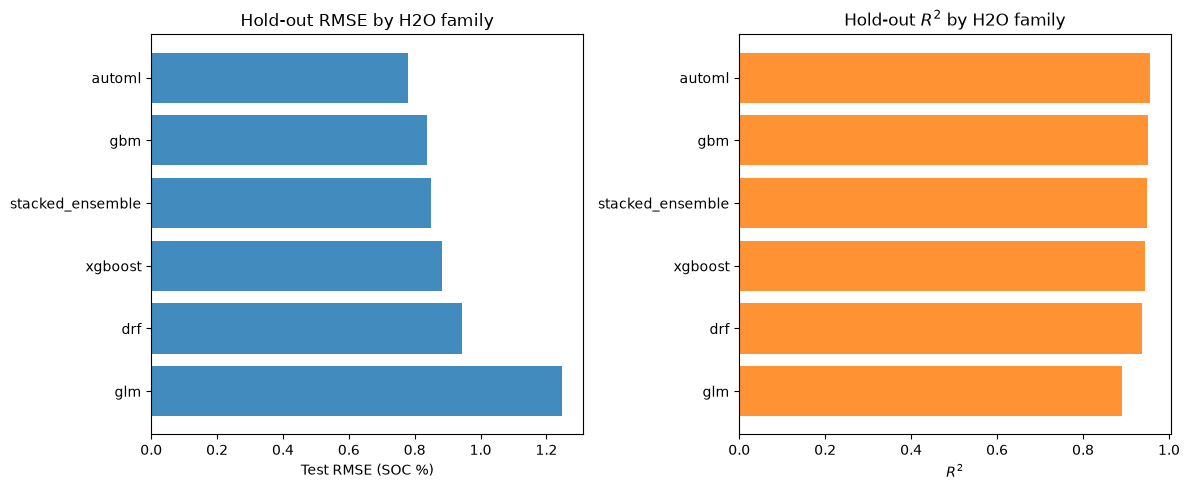

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
order = results.sort_values("test_rmse")
axes[0].barh(order["family"], order["test_rmse"], color="C0", alpha=0.85)
axes[0].set_xlabel("Test RMSE (SOC %)")
axes[0].set_title("Hold-out RMSE by H2O family")
axes[0].invert_yaxis()

axes[1].barh(order["family"], order["test_r2"], color="C1", alpha=0.85)
axes[1].set_xlabel("$R^2$")
axes[1].set_title("Hold-out $R^2$ by H2O family")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()



### Observed vs predicted on the test set

One-to-one plots for the best family and a few representative alternatives.



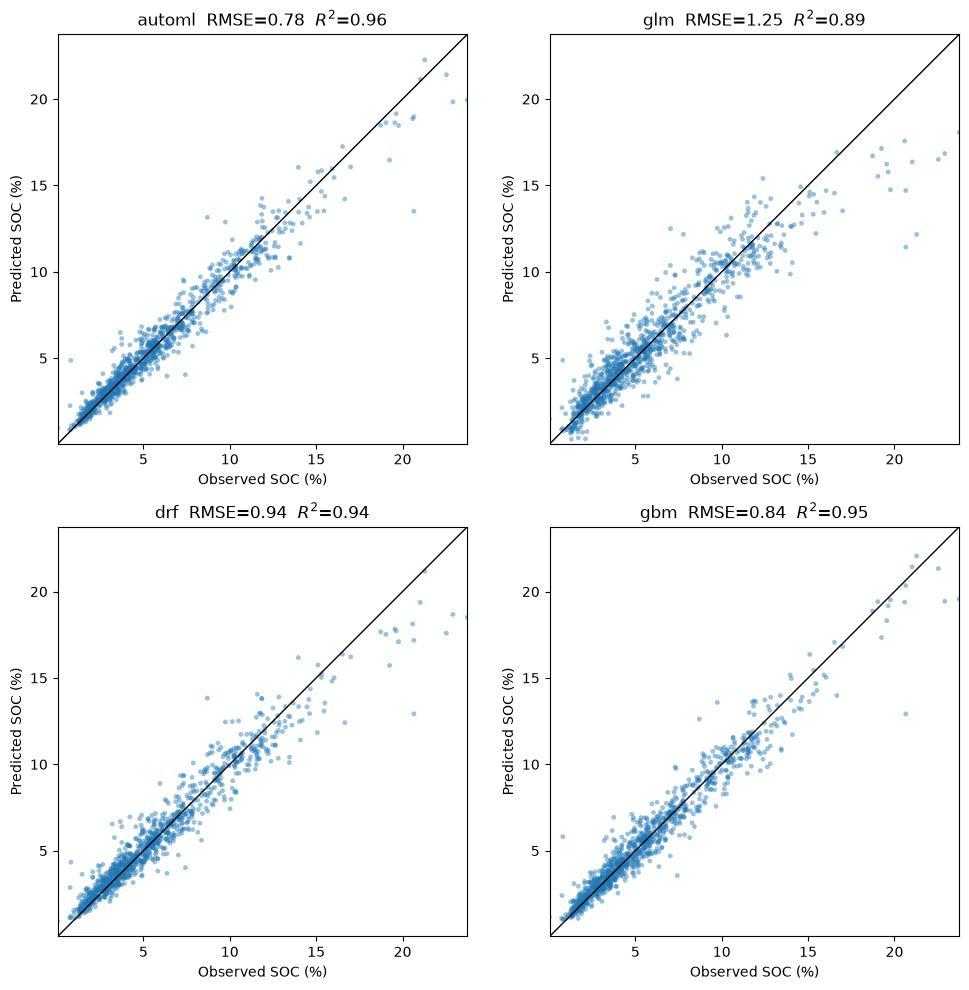

In [13]:
show = [best_name]
for extra in ("glm", "drf", "gbm", "xgboost", "stacked_ensemble", "automl"):
    if extra in fitted and extra not in show:
        show.append(extra)
show = show[:4]

pred_lookup = {row["family"]: row for row in rows}
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
lims = [
    min(y_test.min(), min(pred_lookup[n]["y_pred_test"].min() for n in show)),
    max(y_test.max(), max(pred_lookup[n]["y_pred_test"].max() for n in show)),
]
for ax, name in zip(axes.ravel(), show):
    y_hat = pred_lookup[name]["y_pred_test"]
    ax.scatter(y_test, y_hat, s=12, alpha=0.45, edgecolors="none")
    ax.plot(lims, lims, color="black", linewidth=1)
    ax.set_title(
        f"{name}  RMSE={pred_lookup[name]['test_rmse']:.2f}  "
        f"$R^2$={pred_lookup[name]['test_r2']:.2f}"
    )
    ax.set_xlabel("Observed SOC (%)")
    ax.set_ylabel("Predicted SOC (%)")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
plt.tight_layout()
plt.show()



### Residual variograms of two trend models

The residual variogram depends on the trend: a more flexible H2O model typically leaves **less structured** residual spatial variation (smaller sill / shorter range).



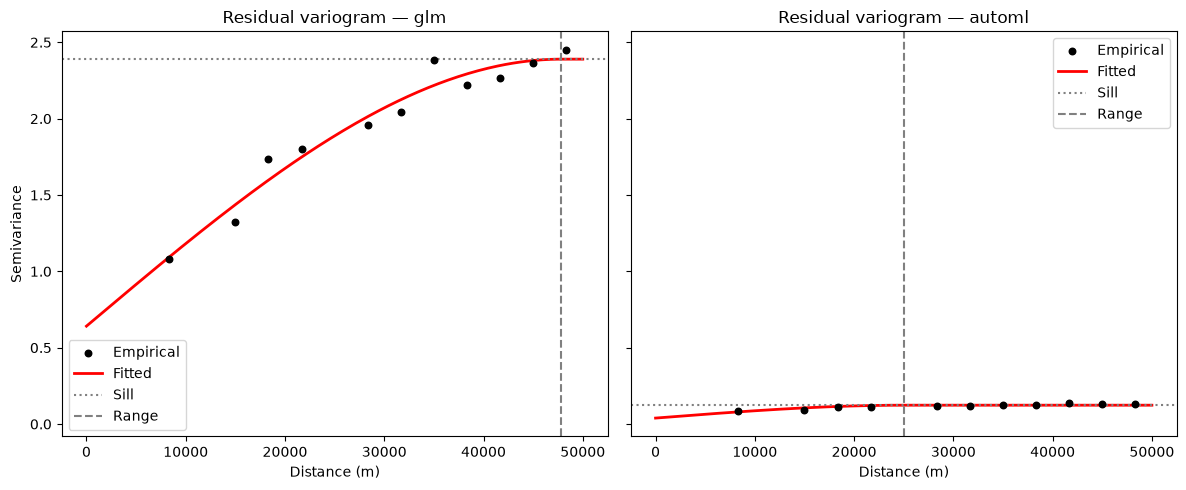

In [14]:
pair = [n for n in ("glm", best_name) if n in fitted]
if len(pair) < 2:
    pair = list(fitted.keys())[:2]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, name in zip(axes, pair):
    vg_r = fitted[name].variogram_
    h_fine = np.linspace(0, vg_r.maxlag, 200)
    ax.scatter(vg_r.lags, vg.experimental if False else vg_r.experimental,
               color="black", s=22, label="Empirical", zorder=3)
    ax.plot(h_fine, vg_r(h_fine), color="red", linewidth=2, label="Fitted")
    nug, ps, rng_r = vg_r.fitted_params
    ax.axhline(nug + ps, color="gray", linestyle=":", label="Sill")
    ax.axvline(rng_r, color="gray", linestyle="--", label="Range")
    ax.set_xlabel("Distance (m)")
    ax.set_title(f"Residual variogram — {name}")
    ax.legend()
axes[0].set_ylabel("Semivariance")
plt.tight_layout()
plt.show()



***
## 10. Feature Importance

Tree families (DRF, GBM, XGBoost) expose H2O variable importance. GLM reports coefficient magnitudes instead. AutoML / stacked ensemble importance is that of the **leader** / metalearner when available.



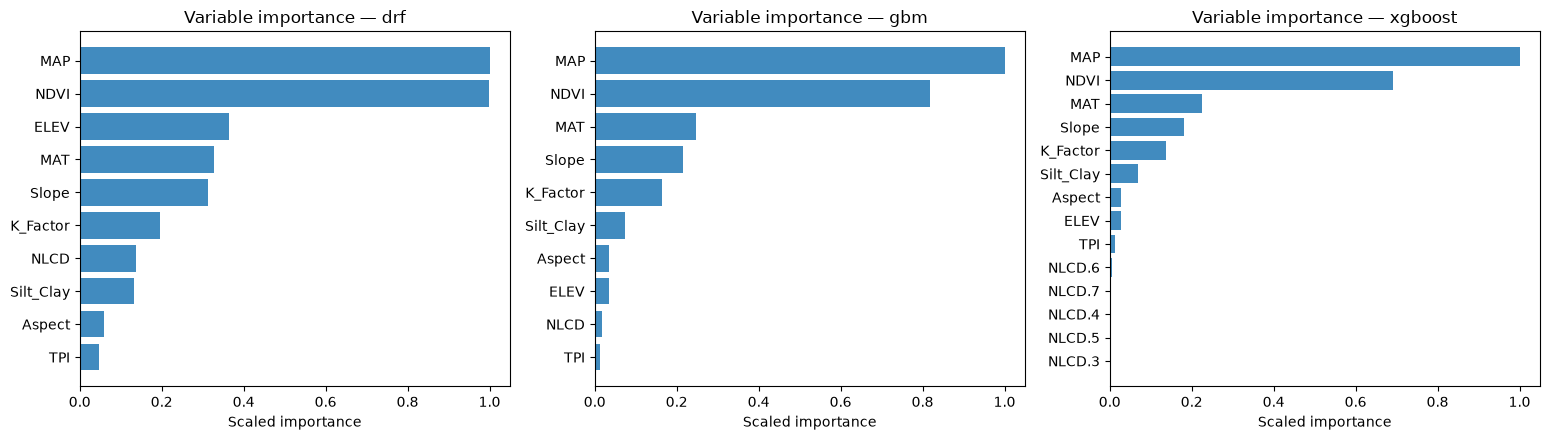

In [15]:
def varimp_series(rk):
    model = rk.best_model_
    try:
        table = model.varimp(use_pandas=True)
    except Exception:
        return None
    if table is None or len(table) == 0:
        return None
    # H2O varimp columns: variable, relative_importance, scaled_importance, percentage
    col = "scaled_importance" if "scaled_importance" in table.columns else table.columns[1]
    return pd.Series(table[col].to_numpy(), index=table["variable"].astype(str))


tree_names = [n for n in ("drf", "gbm", "xgboost", best_name) if n in fitted]
seen = []
for n in tree_names:
    if n not in seen:
        seen.append(n)
tree_names = seen[:3]

fig, axes = plt.subplots(1, max(1, len(tree_names)), figsize=(5.2 * max(1, len(tree_names)), 4.5), sharey=False)
if len(tree_names) <= 1:
    axes = [axes]
for ax, name in zip(np.atleast_1d(axes).ravel(), tree_names):
    imp = varimp_series(fitted[name])
    if imp is None:
        ax.set_title(f"{name}: no varimp")
        ax.axis("off")
        continue
    imp = imp.sort_values()
    ax.barh(imp.index, imp.values, color="C0", alpha=0.85)
    ax.set_title(f"Variable importance — {name}")
    ax.set_xlabel("Scaled importance")
plt.tight_layout()
plt.show()



***
## 11. Predict SOC on Grid Locations

Each fitted family predicts at the `gp_grid.csv` nodes. For the best family we also store the **regression-only** surface, **kriged residuals**, and kriging standard error.



In [16]:
print("Predicting SOC on the grid for every regression family ...")
for name, rk in fitted.items():
    grid_df[f"SOC_{name}"] = rk.predict(X_grid, coords_grid)

best_rk = fitted[best_name]
soc_best, se_best = best_rk.predict(X_grid, coords_grid, return_std=True)
grid_df["SOC_best"] = soc_best
grid_df["SOC_best_se"] = se_best

# Regression-only trend = RK prediction minus kriged residual
grid_df["resid_best"] = best_rk.krige_.predict(coords_grid)
grid_df["reg_best"] = grid_df["SOC_best"] - grid_df["resid_best"]

print(grid_df[["x", "y", "SOC_best", "SOC_best_se", "reg_best", "resid_best"]].describe())




Predicting SOC on the grid for every regression family ...
Parse progress: |

████████████████████████████████████████████████████████████████| (done) 100%
glm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


/home/zia207/.pyenv/versions/3.11.16/lib/python3.11/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


Parse progress: |

████████████████████████████████████████████████████████████████| (done) 100%
drf prediction progress: |

...

Parse progress: |

████████████████████████████████████████████████████████████████| (done) 100%
stackedensemble prediction progress: |

███████████████████████████████████████████| (done) 100%


/home/zia207/.pyenv/versions/3.11.16/lib/python3.11/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


                 x           y  SOC_best  SOC_best_se  reg_best  resid_best
count    10674.000   10674.000 10674.000    10674.000 10674.000   10674.000
mean   -753412.225 1757164.871     5.999        0.238     6.008      -0.008
std     327749.190  382369.477     3.604        0.149     3.606       0.233
min   -1245285.000 1003795.000     0.389        0.000     0.769      -4.568
25%   -1005285.000 1503795.000     3.247        0.000     3.266      -0.094
50%    -825285.000 1743795.000     5.112        0.324     5.110      -0.007
75%    -625285.000 2023795.000     7.925        0.335     7.947       0.071
max     114715.000 2533795.000    23.482        0.352    22.887       3.141


In [17]:
out_path = DATA_DIR / "gp_prediction_RK_h2o.csv"
grid_df.to_csv(out_path, index=False)
print(f"Grid predictions saved to {out_path}")




Grid predictions saved to ../data/gp_prediction_RK_h2o.csv


***
## 12. Map Predictions

Points are plotted in EPSG:5070 with Great Plains state boundaries (`data/GP_STATE.shp`).



In [18]:
states = gpd.read_file(DATA_DIR / "GP_STATE.shp")
gdf_pred = gpd.GeoDataFrame(
    grid_df,
    geometry=gpd.points_from_xy(grid_df.x, grid_df.y),
    crs="EPSG:5070",
)
states = states.to_crs(gdf_pred.crs)


def map_points(ax, column, cmap, title, vmin=None, vmax=None):
    gdf_pred.plot(
        column=column, ax=ax, legend=True, cmap=cmap,
        markersize=4, vmin=vmin, vmax=vmax,
        legend_kwds={"shrink": 0.7},
    )
    states.boundary.plot(ax=ax, color="black", linewidth=0.4)
    ax.set_title(title)
    ax.set_axis_off()



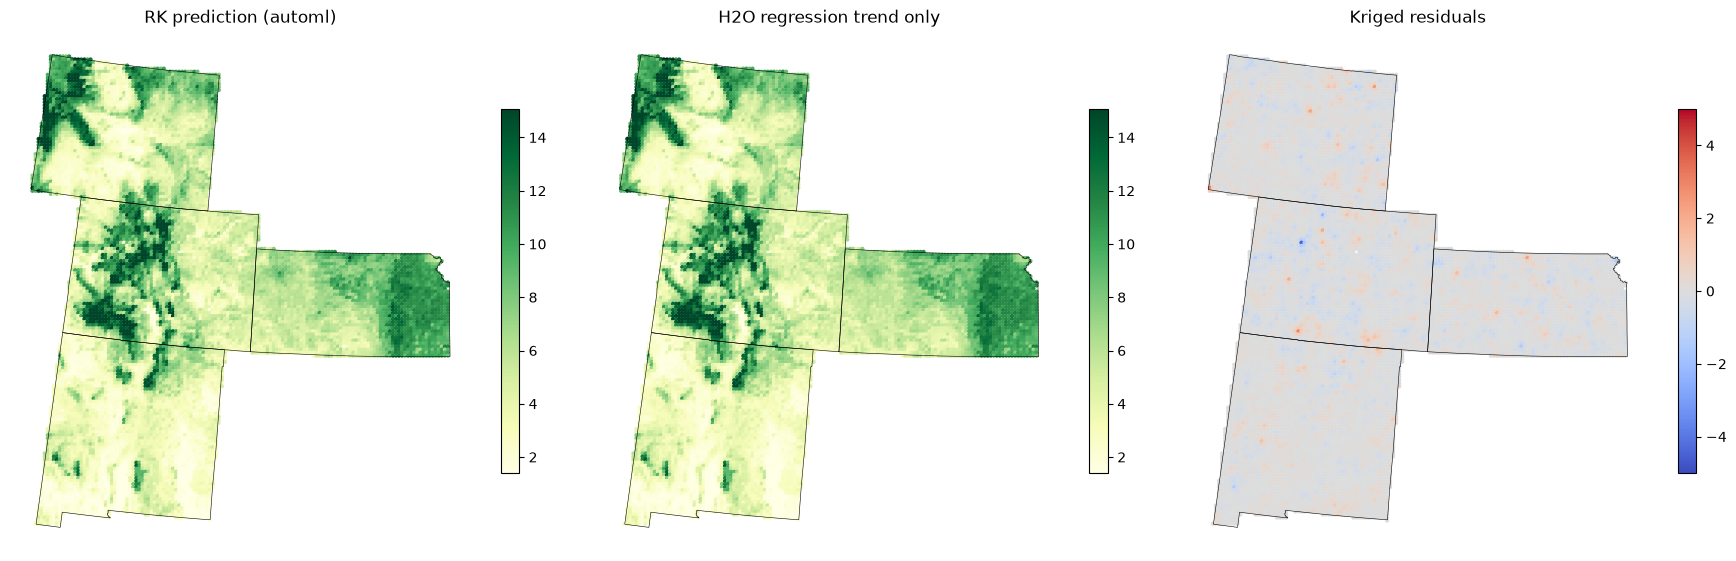

In [19]:
vmin = np.nanpercentile(grid_df["SOC_best"], 2)
vmax = np.nanpercentile(grid_df["SOC_best"], 98)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
map_points(axes[0], "SOC_best", "YlGn", f"RK prediction ({best_name})", vmin, vmax)
map_points(axes[1], "reg_best", "YlGn", "H2O regression trend only", vmin, vmax)
map_points(axes[2], "resid_best", "coolwarm", "Kriged residuals",
           vmin=-5, vmax=5)
plt.tight_layout()
plt.show()



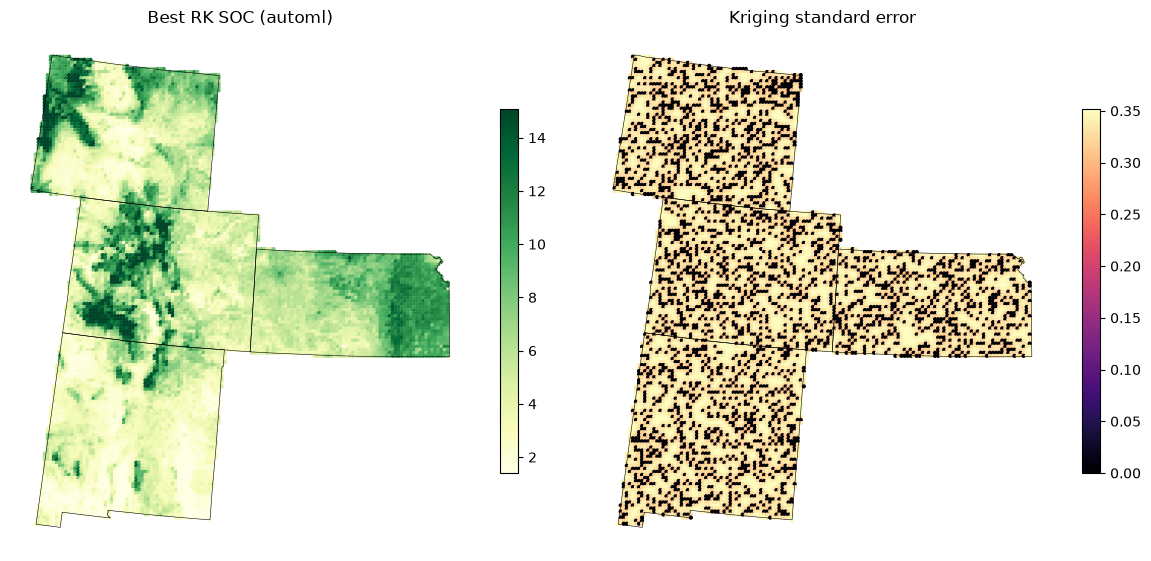

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
map_points(axes[0], "SOC_best", "YlGn", f"Best RK SOC ({best_name})", vmin, vmax)
map_points(axes[1], "SOC_best_se", "magma", "Kriging standard error")
plt.tight_layout()
plt.show()



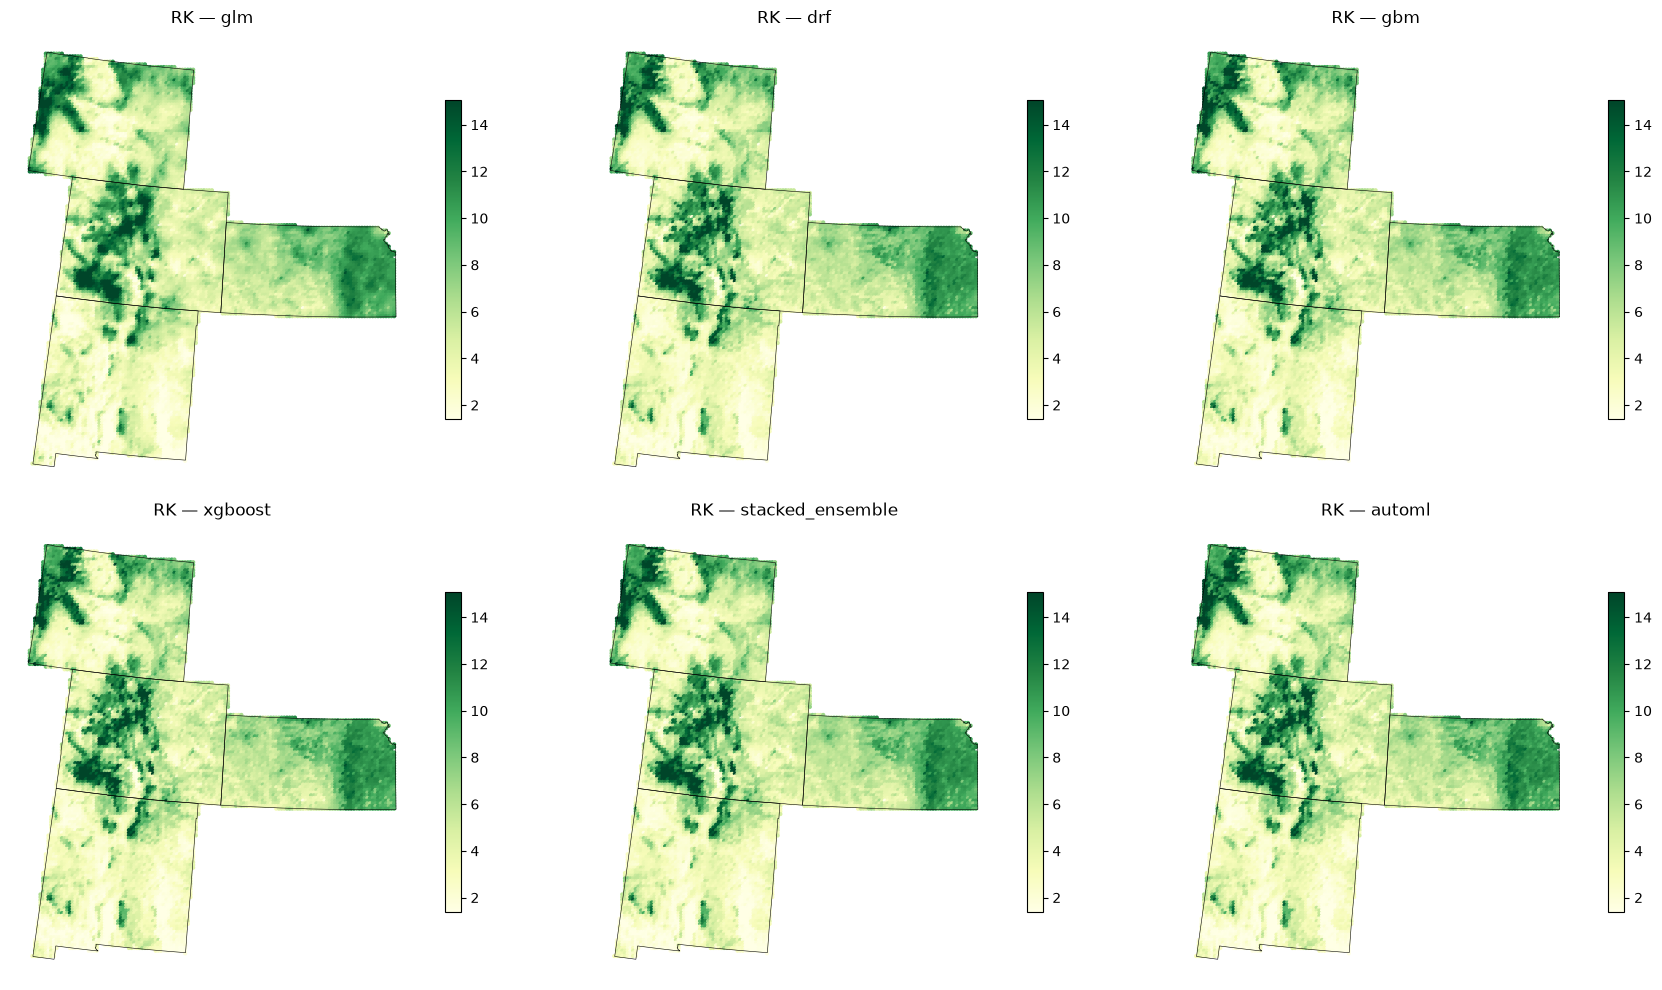

In [21]:
# Side-by-side grid predictions for every SOC-regression family
model_names = list(fitted)
n = len(model_names)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, name in zip(axes, model_names):
    map_points(ax, f"SOC_{name}", "YlGn", f"RK — {name}", vmin, vmax)
for ax in axes[n:]:
    ax.axis("off")
plt.tight_layout()
plt.show()



***
## 13. CPU vs GPU RK Timing

Section 3.1 showed how to *select* a backend. Here we measure how long **residual ordinary kriging** — the spatial step inside `RegressionKrigingH2O` — takes on **CPU** (`use_gpu=False`, NumPy/SciPy) versus **GPU** (`use_gpu=True`, CuPy) for prefixes of the Great Plains SOC survey (`data/gp_data_5000.csv`, $n$ up to 5{,}000).

The H2O trend (GLM / DRF / GBM / …) always runs on the JVM. The GPU-accelerated steps are the $n \times n$ residual covariance among training points, the $n_{\text{pred}} \times n$ covariance to the targets, and the linear solve of the **augmented** OK system. A linear trend (the GLM analogue) is fit once per prefix so the residual field is comparable to H2O GLM; that fit and the residual variogram are **not** included in the OK times.

Two practical notes:

- **Small $n$ and few targets** (a few hundred training *and* prediction points) often shows little GPU gain: host→device copies and kernel-launch overhead dominate.
- **Larger $n$**, or a **dense prediction grid**, is where the GPU pays off: the OK system scales as $O(n^3)$ for the solve and $O(n \cdot n_{\text{pred}})$ for the target covariances.

Each timing is the **median** of three `OrdinaryKriging.fit` + `predict(..., return_variance=True)` calls after a short GPU warmup so CUDA kernel compilation is not counted. If CuPy cannot run a kernel here, the GPU column is skipped and only CPU times are reported.


GPU usable : True
Repeats    : 3  (median wall time of residual OK fit + predict)
GP SOC     : 5000 samples from data/gp_data_5000.csv
Trend      : linear (H2O GLM analogue; residual OK uses use_gpu)
GP n_pred  : 500 grid locations

 dataset  n_train  n_pred  CPU (ms)  GPU (ms) speedup  match
GP (SOC)      500     500      62.5       9.6   6.53×   True
GP (SOC)     1000     500     165.1      23.5   7.03×   True
GP (SOC)     2000     500     375.7      59.1   6.36×   True
GP (SOC)     4000     500    1335.8     205.4   6.50×   True
GP (SOC)     5000     500    2068.1     350.3   5.90×   True


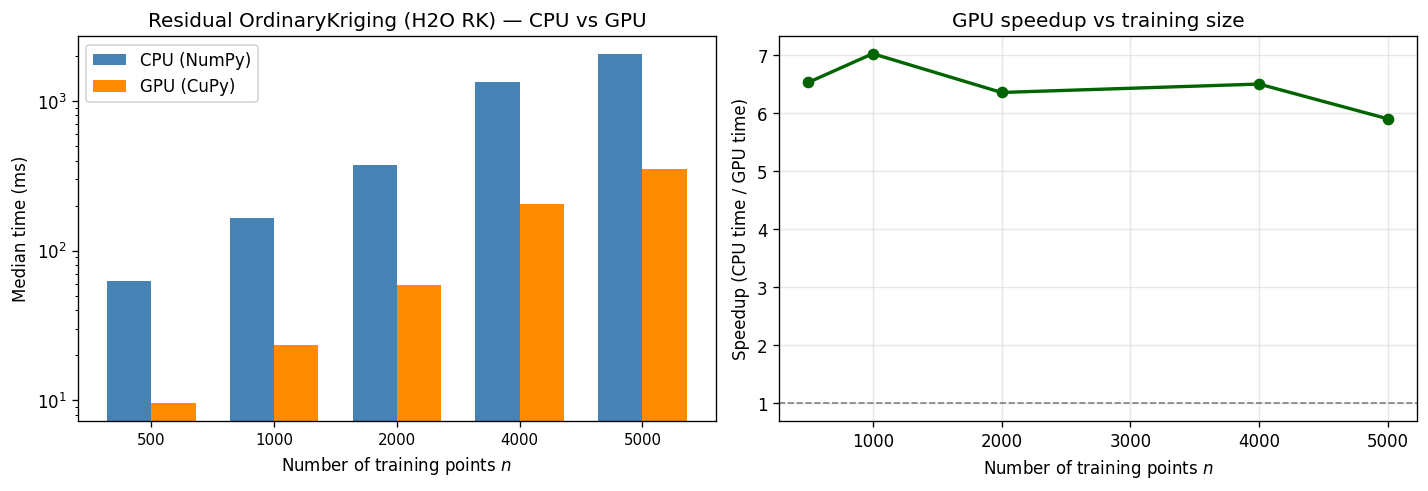

In [22]:
import time
from sklearn.linear_model import LinearRegression

from pygstat import OrdinaryKriging

N_REPEATS = 3
N_PRED_GP = 500
GP_SIZES = [500, 1000, 2000, 4000, 5000]
rng_bench = np.random.default_rng(42)

pred_idx = rng_bench.choice(len(coords_grid), size=N_PRED_GP, replace=False)
xy_pred_b = coords_grid[pred_idx]


def _residual_variogram(X_tr, y_tr, xy_tr):
    """GLM-style linear trend (CPU); residual field is what OK interpolates."""
    lin = LinearRegression().fit(np.asarray(X_tr, dtype=float), y_tr)
    resid = y_tr - lin.predict(np.asarray(X_tr, dtype=float))
    vg_kw = dict(VARIOGRAM_KWARGS)
    vg_kw.pop("use_gpu", None)
    return Variogram(
        np.asarray(xy_tr, dtype=float),
        np.asarray(resid, dtype=float),
        model="spherical",
        estimator="matheron",
        use_gpu=False,
        **vg_kw,
    ).fit(), resid


def _time_ok(xy_train, z_train, xy_pred, vg, use_gpu, repeats=N_REPEATS, warmup=True):
    """Median wall time of OrdinaryKriging.fit + predict(return_variance=True)."""
    if warmup:
        k_tr = min(40, len(xy_train))
        k_pr = min(40, len(xy_pred))
        OrdinaryKriging(vg, use_gpu=use_gpu).fit(
            xy_train[:k_tr], z_train[:k_tr]
        ).predict(xy_pred[:k_pr], return_variance=True)
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
    times = []
    last = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        ok_m = OrdinaryKriging(vg, use_gpu=use_gpu).fit(xy_train, z_train)
        last = ok_m.predict(xy_pred, return_variance=True)
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.median(times)), last


print(f"GPU usable : {USE_GPU}")
print(f"Repeats    : {N_REPEATS}  (median wall time of residual OK fit + predict)")
print(f"GP SOC     : {len(y)} samples from data/gp_data_5000.csv")
print("Trend      : linear (H2O GLM analogue; residual OK uses use_gpu)")
print(f"GP n_pred  : {N_PRED_GP} grid locations")
print()

rows = []
for n in GP_SIZES:
    X_tr = np.asarray(X.iloc[:n] if hasattr(X, "iloc") else X[:n], dtype=float)
    y_tr = y[:n]
    xy_tr = coords[:n]
    vg, resid = _residual_variogram(X_tr, y_tr, xy_tr)

    cpu_t, pred_cpu = _time_ok(xy_tr, resid, xy_pred_b, vg, use_gpu=False)
    row = {
        "dataset": "GP (SOC)",
        "n_train": n,
        "n_pred": N_PRED_GP,
        "CPU (s)": cpu_t,
        "GPU (s)": np.nan,
        "speedup": np.nan,
        "match": "—",
    }
    if USE_GPU:
        gpu_t, pred_gpu = _time_ok(xy_tr, resid, xy_pred_b, vg, use_gpu=True)
        row["GPU (s)"] = gpu_t
        row["speedup"] = cpu_t / gpu_t
        z_c, se_c = pred_cpu
        z_g, se_g = pred_gpu
        row["match"] = bool(
            np.allclose(z_c, z_g, rtol=1e-4, atol=1e-4, equal_nan=True)
            and np.allclose(se_c, se_g, rtol=1e-4, atol=1e-4, equal_nan=True)
        )
        import cupy as cp
        cp.get_default_memory_pool().free_all_blocks()
    rows.append(row)

df_bench = pd.DataFrame(rows)
df_show = df_bench.copy()
df_show["CPU (ms)"] = (df_show["CPU (s)"] * 1000).round(1)
df_show["GPU (ms)"] = (df_show["GPU (s)"] * 1000).round(1)
df_show["speedup"] = df_show["speedup"].map(
    lambda x: "—" if pd.isna(x) else f"{x:.2f}×"
)
print(df_show[["dataset", "n_train", "n_pred", "CPU (ms)", "GPU (ms)", "speedup", "match"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
n_vals = df_bench["n_train"].to_numpy()
cpu_ms = df_bench["CPU (s)"].to_numpy() * 1000
gpu_ms = df_bench["GPU (s)"].to_numpy() * 1000
labels = [str(int(n)) for n in n_vals]

x = np.arange(len(n_vals))
w = 0.36
axes[0].bar(x - w / 2, cpu_ms, w, label="CPU (NumPy)", color="steelblue")
if USE_GPU and np.isfinite(gpu_ms).all():
    axes[0].bar(x + w / 2, gpu_ms, w, label="GPU (CuPy)", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=9)
axes[0].set_xlabel("Number of training points $n$")
axes[0].set_ylabel("Median time (ms)")
axes[0].set_title("Residual OrdinaryKriging (H2O RK) — CPU vs GPU")
axes[0].legend()
axes[0].set_yscale("log")

if USE_GPU:
    axes[1].plot(n_vals, df_bench["speedup"], "o-", color="darkgreen", lw=2)
    axes[1].axhline(1.0, color="grey", ls="--", lw=1)
    axes[1].set_xlabel("Number of training points $n$")
    axes[1].set_ylabel("Speedup (CPU time / GPU time)")
    axes[1].set_title("GPU speedup vs training size")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(
        0.5, 0.5,
        "GPU not usable in this environment\nCPU-only timings shown",
        ha="center", va="center", transform=axes[1].transAxes,
    )
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


Predictions and residual-kriging standard errors from the two backends should **match** (`match = True`). The H2O trend is the same on both runs; the GPU speedup comes from the residual OK covariance build and solve. On the Great Plains SOC prefixes the $O(n^2)$ covariance and $O(n^3)$ solve keep the GPU several times faster as $n$ grows to 5{,}000. Use `use_gpu=USE_GPU` (as the rest of this notebook does) so the same cells run on a laptop CPU or a CUDA workstation without edits.


***
## 14. Summary and Conclusions

This notebook applied **regression kriging** to Great Plains **soil organic carbon** with **H2O-3** trend models (`pygstat.RegressionKrigingH2O`).

- **Data.** 5,000 samples (`gp_data_5000.csv`) and a 10 km grid (`gp_grid.csv`). **NLCD** is a **categorical** factor, not an ordinal score.
- **Split.** NLCD-stratified **60% train / 20% valid / 20% test**. Train fits the trend and residual kriging; valid is the H2O validation / leaderboard frame for **hyperparameter tuning**; test is used only for the final comparison.
- **Families.** GLM, DRF, GBM, XGBoost (if available), stacked ensemble, and AutoML were each tuned (or searched) on train+valid. The **best model of each family** was scored on the test set and used to map SOC on the grid.
- **Mapping.** SOC, the H2O trend, kriged residuals, and kriging standard error were written to `data/gp_prediction_RK_h2o.csv`.
- **CPU / GPU.** Residual ordinary kriging (`use_gpu=USE_GPU`) was timed on prefixes of `gp_data_5000.csv`. The H2O trend stays on the JVM; the $O(n^2)$ covariance and $O(n^3)$ OK solve are the GPU-accelerated steps.

Regression kriging with H2O is a practical workflow when you want **native categorical encoding**, **grid search / AutoML**, and **geostatistical residuals** on the same spatial support.


***
## 15. Resources

### Papers and books

| Reference | Notes |
|-----------|-------|
| Hengl, T., Heuvelink, G.B.M. & Stein, A. (2004). A generic framework for spatial prediction of soil variables based on regression-kriging. *Geoderma* 120, 75–93. | RK as used in digital soil mapping |
| Hengl, T., Heuvelink, G.B.M. & Rossiter, D.G. (2007). About regression-kriging: from equations to case studies. *Computers & Geosciences* 33, 1301–1315. | Practical RK workflow |
| Odeh, I.O.A., McBratney, A.B. & Chittleborough, D.J. (1995). Further results on prediction of soil properties from terrain attributes: heterotopic cokriging and regression-kriging. *Geoderma* 67, 215–226. | Early RK for soil properties |
| Goovaerts, P. (1997). *Geostatistics for Natural Resources Evaluation*. Oxford University Press. | SK with a varying local mean |
| LeDell, E. & Poirier, S. (2020). H2O AutoML: Scalable automatic machine learning. *7th ICML Workshop on Automated Machine Learning*. | AutoML leader and stacked ensembles |

### In this library

| Object | Role |
|--------|------|
| `pygstat.RegressionKrigingH2O` | H2O trend + ordinary kriging of residuals (`use_gpu`) |
| `H2O_MODEL_TYPES` | `'glm'`, `'drf'`, `'gbm'`, `'xgboost'`, `'stacked_ensemble'`, `'automl'`, … |
| `categorical_columns` | Columns converted to H2O factors (here, `NLCD`) |
| `fit(..., X_valid=, y_valid=)` | Validation frame for tuning / AutoML leaderboard |
| `pygstat.Variogram` | Residual (and exploratory) variogram |

When you are finished with the local H2O cluster you can run `h2o.cluster().shutdown()`.

